# Coherent States Under Random Displacement Noise

Two distinguishable coherent states $|{+\alpha}\rangle$ and $|{-\alpha}\rangle$ are Gaussian blobs in phase space:

$$W_{|\pm\alpha\rangle}(q, p) = \frac{2}{\pi}\,e^{-2[(q \mp \alpha)^2 + p^2]}$$

After the displacement error channel with noise strength $\sigma$, the Wigner function broadens analytically:

$$W_{|\pm\alpha\rangle}^{\rm noisy}(q, p) = \frac{2/\pi}{1 + 2\sigma^2}\exp\!\left(-\frac{2[(q \mp \alpha)^2 + p^2]}{1 + 2\sigma^2}\right)$$

As $\sigma$ grows the two peaks broaden and overlap — the states become indistinguishable and information is lost.

QEC narrows the effective displacement distribution, keeping the peaks sharper and better separated.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from matplotlib.patches import Patch

N    = 400
L    = 5.0
q    = np.linspace(-L, L, N)
dq   = q[1] - q[0]
Q, P_grid = np.meshgrid(q, q)

alpha    = 1.5   # coherent state displacement |±alpha>
vmax_coh = 2 / np.pi   # peak of clean coherent Wigner function

def G(x, sigma):
    return np.exp(-x**2 / sigma**2) / (np.sqrt(np.pi) * sigma)

def W_coh_clean(q0):
    """Wigner function of coherent state |q0> (no noise)."""
    return (2/np.pi) * np.exp(-2 * ((Q - q0)**2 + P_grid**2))

def W_coh_noisy(q0, sigma):
    """Analytical Wigner function of |q0> after Gaussian displacement noise sigma."""
    return (2/np.pi) / (1 + 2*sigma**2) * np.exp(
        -2 * ((Q - q0)**2 + P_grid**2) / (1 + 2*sigma**2))

## Information Loss — Four Noise Levels

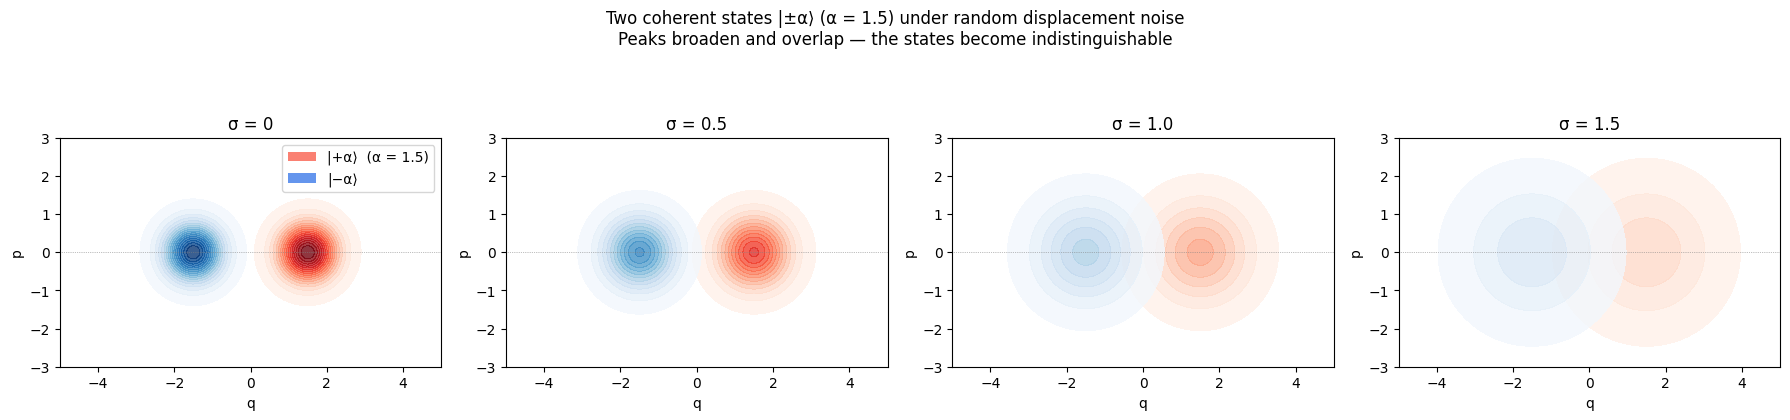

In [9]:
sigmas_coh = [0, 0.5, 1.0, 1.5]
lvls = np.linspace(0.02 * vmax_coh, vmax_coh, 18)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, sigma in zip(axes, sigmas_coh):
    W_p = W_coh_clean( alpha)    if sigma == 0 else W_coh_noisy( alpha, sigma)
    W_m = W_coh_clean(-alpha)    if sigma == 0 else W_coh_noisy(-alpha, sigma)
    ax.contourf(Q, P_grid, W_p, levels=lvls, cmap='Reds',  alpha=0.8)
    ax.contourf(Q, P_grid, W_m, levels=lvls, cmap='Blues', alpha=0.8)
    ax.set_title(f'\u03c3 = {sigma}')
    ax.set_xlabel('q')
    ax.set_ylabel('p')
    ax.set_aspect('equal')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)

legend_elements = [Patch(facecolor='salmon',        label=f'|+\u03b1\u27e9  (\u03b1 = {alpha})'),
                   Patch(facecolor='cornflowerblue', label='|\u2212\u03b1\u27e9')]
axes[0].legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.suptitle(f'Two coherent states |\u00b1\u03b1\u27e9 (\u03b1 = {alpha}) under random displacement noise\n'
             'Peaks broaden and overlap \u2014 the states become indistinguishable', fontsize=12)
plt.tight_layout()
plt.savefig('wigner_maps_coherent_states.pdf', bbox_inches='tight')
plt.savefig('wigner_maps_coherent_states.svg', bbox_inches='tight')
plt.show()

## Effect of QEC on State Distinguishability

QEC replaces the Gaussian noise kernel with a corrected distribution $P_{\rm corr}(\beta)$ that is narrower, reducing effective smearing. The noisy Wigner function is computed via convolution:

$$W^{\rm noisy}(q,p) = \iint P_{\rm corr}(\beta_q, \beta_p)\, W_{\rm clean}(q-\beta_q, p-\beta_p)\, d\beta_q\, d\beta_p$$

**Squeezing + 1-qubit QEC**: squeezes the mode to reduce $p$-noise, then applies 1-qubit QEC on $p$. Variance reduced by 20.5%.  
**2-qubit QEC**: applies one qubit per quadrature independently. Variance reduced by 36.8% per quadrature.

In [10]:
zeta_opt = (1/8) * np.log(1 - np.exp(-1))   # optimal squeezing parameter

def apply_kernel(W_in, K):
    """Convolve Wigner function with normalised kernel K."""
    return fftconvolve(W_in, K, mode='same') * dq**2

def K_no_qec(sigma):
    K = np.exp(-(Q**2 + P_grid**2) / sigma**2) / (np.pi * sigma**2)
    return K / (K.sum() * dq**2)

def K_squeezing_qec(sigma):
    sigma_q = sigma * np.exp(2 * zeta_opt)
    sigma_p = sigma * np.exp(-2 * zeta_opt)
    a_p  = 1 / (np.sqrt(8) * sigma_p)
    bbar = 2 * a_p * sigma_p**2 * np.exp(-4 * a_p**2 * sigma_p**2)
    P_plus  = G(P_grid + bbar, sigma_p) * (1 + np.sin(4*a_p*(P_grid + bbar)))
    P_minus = G(P_grid - bbar, sigma_p) * (1 - np.sin(4*a_p*(P_grid - bbar)))
    K = G(Q, sigma_q) * np.clip(0.5*(P_plus + P_minus), 0, None)
    return K / (K.sum() * dq**2)

def K_2qubit_qec(sigma):
    a    = 1 / (np.sqrt(8) * sigma)
    bbar = 2 * a * sigma**2 * np.exp(-4 * a**2 * sigma**2)
    P_p = 0.5 * (G(P_grid + bbar, sigma) * (1 + np.sin(4*a*(P_grid + bbar))) +
                 G(P_grid - bbar, sigma) * (1 - np.sin(4*a*(P_grid - bbar))))
    P_q = 0.5 * (G(Q - bbar, sigma) * (1 - np.sin(4*a*(Q - bbar))) +
                 G(Q + bbar, sigma) * (1 + np.sin(4*a*(Q + bbar))))
    K = np.clip(P_q * P_p, 0, None)
    return K / (K.sum() * dq**2)

sigma_qec = 0.5

W_p_clean = W_coh_clean( alpha)
W_m_clean = W_coh_clean(-alpha)

K_no = K_no_qec(sigma_qec)
K_sq = K_squeezing_qec(sigma_qec)
K_2q = K_2qubit_qec(sigma_qec)

W_p_no = apply_kernel(W_p_clean, K_no);  W_m_no = apply_kernel(W_m_clean, K_no)
W_p_sq = apply_kernel(W_p_clean, K_sq);  W_m_sq = apply_kernel(W_m_clean, K_sq)
W_p_2q = apply_kernel(W_p_clean, K_2q);  W_m_2q = apply_kernel(W_m_clean, K_2q)

print(f'\u03c3 = {sigma_qec}')
print(f'No QEC     |+\u03b1\u27e9 peak: {W_p_no.max():.4f}   (clean: {vmax_coh:.4f})')
print(f'Sq+1-qubit |+\u03b1\u27e9 peak: {W_p_sq.max():.4f}')
print(f'2-qubit    |+\u03b1\u27e9 peak: {W_p_2q.max():.4f}')

σ = 0.5
No QEC     |+α⟩ peak: 0.4244   (clean: 0.6366)
Sq+1-qubit |+α⟩ peak: 0.4601
2-qubit    |+α⟩ peak: 0.4912


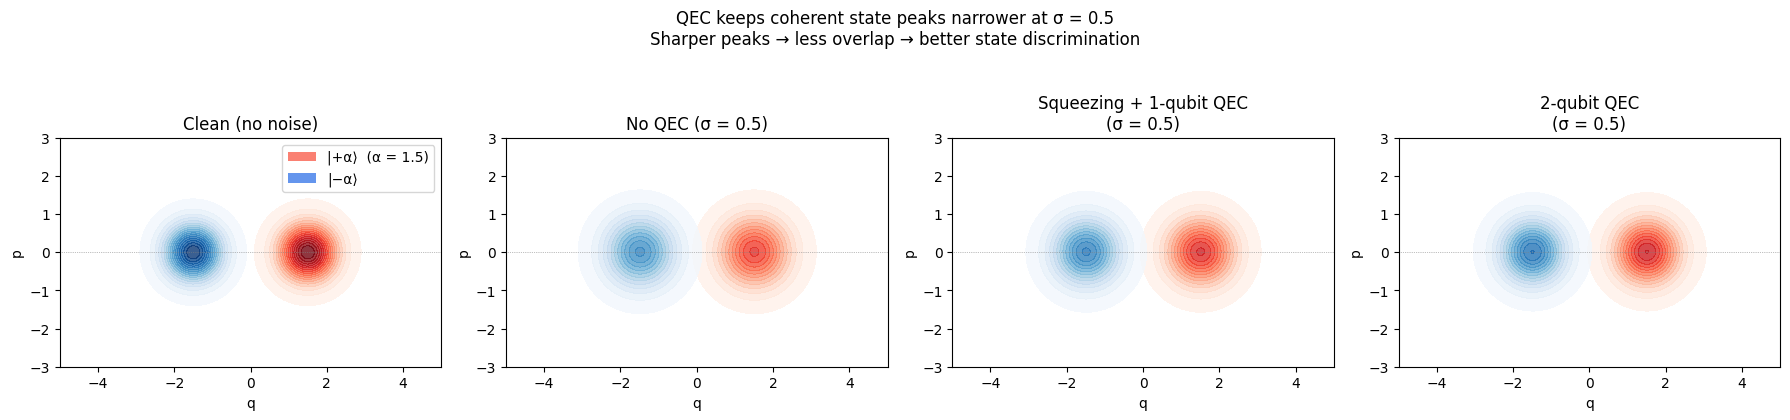

In [11]:
lvls_qec = np.linspace(0.02 * vmax_coh, vmax_coh, 18)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

all_pairs = [(W_p_clean, W_m_clean),
             (W_p_no,    W_m_no),
             (W_p_sq,    W_m_sq),
             (W_p_2q,    W_m_2q)]
titles    = ['Clean (no noise)',
             f'No QEC (\u03c3 = {sigma_qec})',
             f'Squeezing + 1-qubit QEC\n(\u03c3 = {sigma_qec})',
             f'2-qubit QEC\n(\u03c3 = {sigma_qec})']

for ax, (W_p, W_m), title in zip(axes, all_pairs, titles):
    ax.contourf(Q, P_grid, W_p, levels=lvls_qec, cmap='Reds',  alpha=0.8)
    ax.contourf(Q, P_grid, W_m, levels=lvls_qec, cmap='Blues', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('q')
    ax.set_ylabel('p')
    ax.set_aspect('equal')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)

legend_elements = [Patch(facecolor='salmon',        label=f'|+\u03b1\u27e9  (\u03b1 = {alpha})'),
                   Patch(facecolor='cornflowerblue', label='|\u2212\u03b1\u27e9')]
axes[0].legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.suptitle(f'QEC keeps coherent state peaks narrower at \u03c3 = {sigma_qec}\n'
             'Sharper peaks \u2192 less overlap \u2192 better state discrimination', fontsize=12)
plt.tight_layout()
plt.savefig('wigner_maps_coherent_QEC.pdf', bbox_inches='tight')
plt.savefig('wigner_maps_coherent_QEC.svg', bbox_inches='tight')
plt.show()